In [23]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import hvplot.xarray
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from scipy.optimize import curve_fit

[-1.01777118e-11  8.73273595e-10 -3.25449125e-08  6.88424669e-07
 -9.06072649e-06  7.65499707e-05 -4.15117124e-04  1.42418609e-03
 -3.03141088e-03  3.38846022e-03 -1.76901593e-03 -2.26326842e-03
  9.99984423e-01]


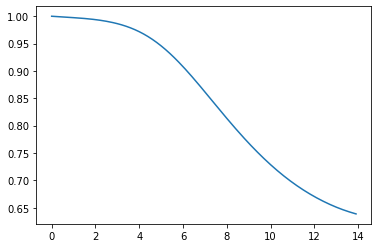

In [ ]:
calib_dir = 'C:/Users/RalphGroup/Documents/group_code/daedalus_control/calibrations/2024-07-15_daedalus_calib/'
field_correction_coeff= np.loadtxt(calib_dir + 'daedalus_fieldratio_calib.csv', delimiter=',')
field_correction_calib = np.poly1d(field_correction_coeff)
R1 = np.arange(-14, 14, 0.1)
plt.plot(R1, field_correction_calib(R1))
print(field_correction_coeff)

In [29]:
measured = pd.read_csv('F:/Dan P/Daedalus Calibrations/2025-06-27/test_daedalus_radialPolar_calib_A000.0_2025-06-27_2.csv', comment = '#', index_col = 'theta')
ds = xr.Dataset(measured)
#ds = ds.where(ds.R < 16, drop=True)

[-5.66026306e-14  4.07307991e-14  4.85575684e-11 -3.16148215e-11
 -1.62008785e-08  9.39238698e-09  2.60047189e-06 -1.32295181e-06
 -1.88472243e-04  8.68801935e-05  1.78494510e-03 -2.94972754e-03
  9.89800253e-01]


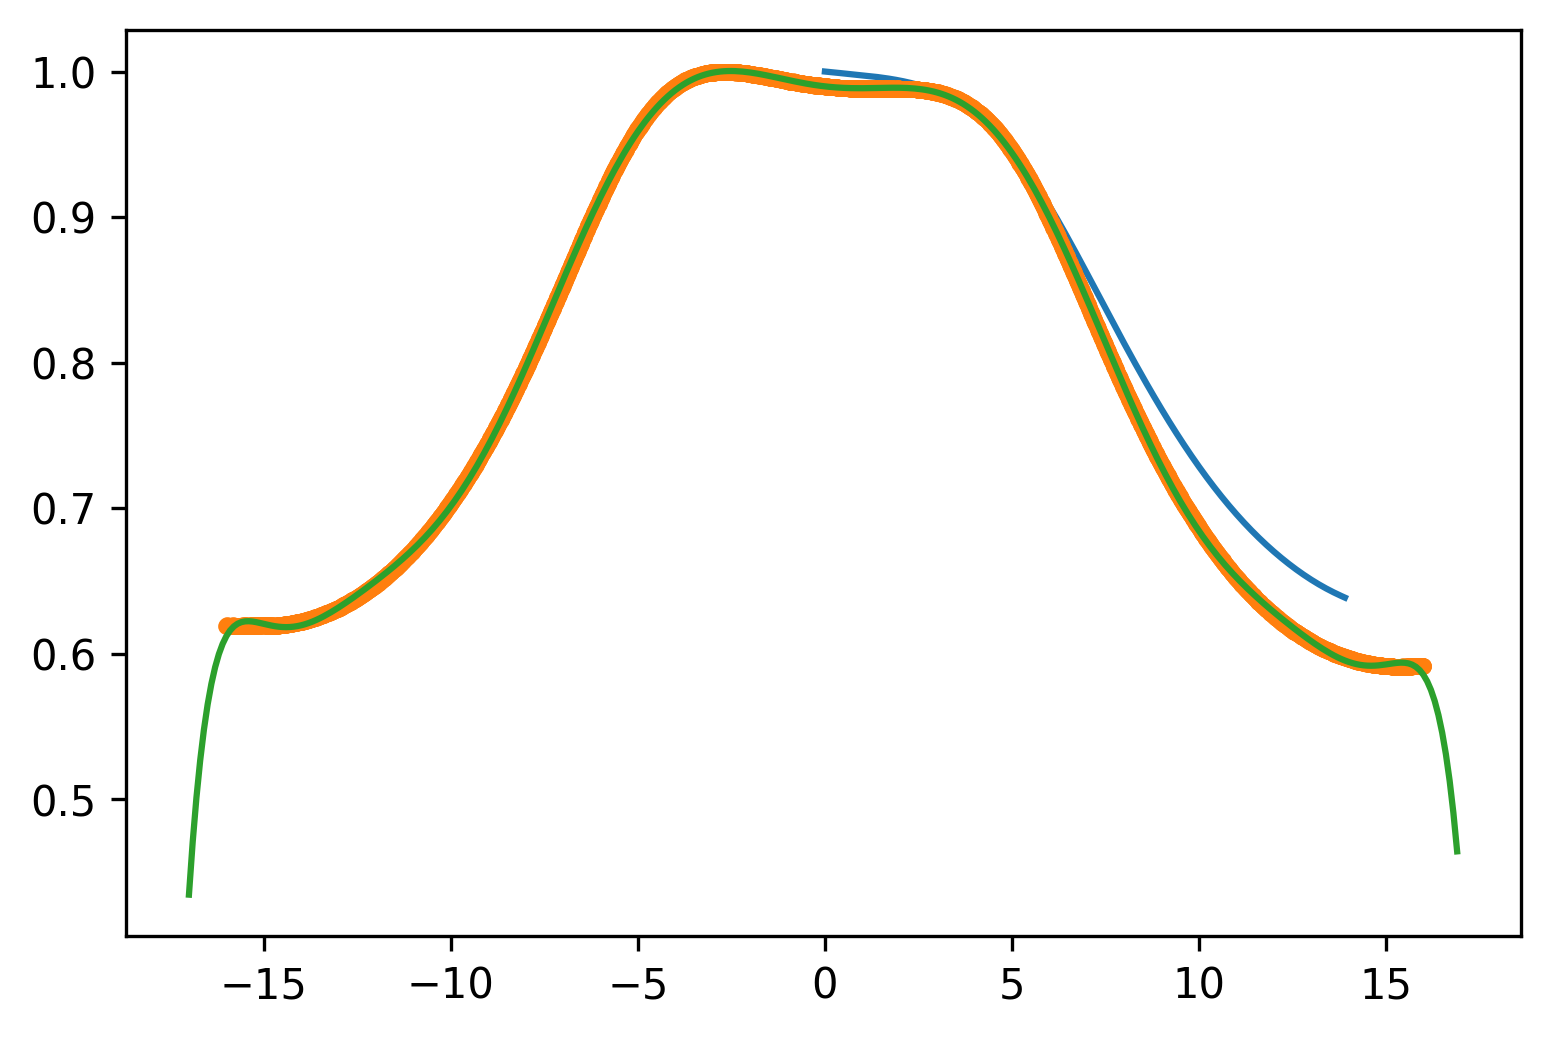

In [30]:
plt.figure(dpi=300)
plt.plot(R1, field_correction_calib(R1))
plt.plot(ds['R'], ds['B']/ds['B'].max(), '.')
R2=np.arange(-17,17,0.1)

field_correction_coeff_new = np.polyfit(ds['R'], ds['B']/ds['B'].max(), 12)
print(field_correction_coeff_new)
field_correction_calib_new = np.poly1d(field_correction_coeff_new)
plt.plot(R2, field_correction_calib_new(R2))
#save to fieldratio (field_correction)